# Fase 6 — Diagnóstico del modo de fallo (sistema PHM de dos componentes)
### TFM: Arquitectura de Mantenimiento Predictivo

Con la prognosis resuelta (XGBoost q0,25, Fases 2--4), esta fase añade la pieza que
completa el ciclo **PHM**: el **diagnóstico**, es decir, ponerle nombre al fallo. El sistema
resultante tiene dos componentes especializados que comparten la misma telemetría de entrada:

- **Prognosis** (¿cuánta vida queda?): XGBoost q0,25, ya entrenado y validado.
- **Diagnóstico** (¿qué componente falla?): el clasificador de esta fase (CNN 1D causal).

**Por qué dos modelos y no un multitarea de cuerpo compartido:** la Fase 5 demostró que, a
esta escala de datos, el cuerpo secuencial es peor que XGBoost para la prognosis. Forzar
ambas tareas a salir de un cuerpo compartido sacrificaría el mejor modelo de RUL. Dos
modelos especializados preservan lo mejor de cada tarea; es la decisión de ingeniería
correcta para este caso, y así se defiende en la memoria.

**Las etiquetas (verificadas contra Arias Chao et al. 2021, Tabla 2):**
DS01 -> HPT · DS02/DS03 -> HPT+LPT · DS04 -> Fan · DS05 -> HPC · DS06 -> HPC+HPT ·
DS07 -> LPT · DS08a/DS08c -> ALL (todos los componentes).

**Tres salvaguardas de honestidad del experimento:**
1. **Sin fuga del subconjunto**: el clasificador solo ve señales físicas (W + X_s). Nunca
   `ds_code` ni `engine_id`. Si los viera, aprendería "de qué fichero viene el motor", no la
   firma física del fallo (la misma trampa que `cycle_norm` en la Fase 1).
2. **Validación por unidad**: motores enteros separados entre entrenamiento y validación, y
   evaluación final sobre la partición de test oficial de cada subconjunto.
3. **Evaluación en zona degradada**: un motor sano aún no expresa su fallo (las clases son
   indistinguibles por física). Se reporta la exactitud global Y la exactitud en la zona
   degradada (RUL < cap), que es donde el diagnóstico tiene sentido y donde se juzga.

Requiere `tensorflow`. No ejecutado en el entorno de generación (sin TensorFlow disponible);
la lógica de ventanas causales es la misma ya validada en la Fase 5. Tiempo: ~15-25 min.

In [1]:
import os, time, warnings
import numpy as np, pandas as pd, h5py, joblib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, r"C:\Users\11jav\Documents\Master\TFM\Notebooks_TFM")
from config import FILES, DATA_DIR

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

RUL_CAP = 57
WINDOW = 30
BATCH_SIZE = 64
EPOCHS = 60
PATIENCE = 8

FILES = {
    'DS01':FILES['DS01'],'DS02':FILES['DS02'],
    'DS03':FILES['DS03'],'DS04':FILES['DS04'],
    'DS05':FILES['DS05'],'DS06':FILES['DS06'],
    'DS07':FILES['DS07'],'DS08a':FILES['DS08a'],
    'DS08c':FILES['DS08c'],
}

# Modo de fallo por subconjunto (Arias Chao et al. 2021, Tabla 2) — la ETIQUETA de diagnóstico
FAULT = {'DS01':'HPT', 'DS02':'HPT+LPT', 'DS03':'HPT+LPT', 'DS04':'Fan',
         'DS05':'HPC', 'DS06':'HPC+HPT', 'DS07':'LPT', 'DS08a':'ALL', 'DS08c':'ALL'}
CLASSES = sorted(set(FAULT.values()))
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

# Agrupación gruesa por zona del motor (fallback si los modos finos se confunden)
GROUP = {'HPT':'Turbina', 'LPT':'Turbina', 'HPT+LPT':'Turbina', 'HPC+HPT':'Mixto_HPC_HPT',
         'HPC':'Compresor', 'Fan':'Fan', 'ALL':'Global'}

present = [n for n, p in FILES.items() if os.path.exists(p)]
print('Subconjuntos:', present)
print('Clases de diagnóstico (finas):', CLASSES)
print('GPU disponible:', len(tf.config.list_physical_devices("GPU")) > 0)

Subconjuntos: ['DS01', 'DS02', 'DS03', 'DS04', 'DS05', 'DS06', 'DS07', 'DS08a', 'DS08c']
Clases de diagnóstico (finas): ['ALL', 'Fan', 'HPC', 'HPC+HPT', 'HPT', 'HPT+LPT', 'LPT']
GPU disponible: False


## 1. Carga como serie por ciclo + etiqueta de fallo

Igual que en la Fase 5 (serie por ciclo de W + X_s, sin ingeniería manual), añadiendo la
etiqueta de modo de fallo del subconjunto. La etiqueta se usa SOLO como objetivo: no entra
como entrada del modelo, y `ds_code` no existe en la matriz de entrada.

In [2]:
def load_subset(path, split, name):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']: df[c] = df[c].astype(int)
    df['engine_id'] = name + '_u' + df['unit'].astype(str)
    df['fault'] = FAULT[name]          # etiqueta de diagnóstico (solo objetivo, nunca entrada)
    return df, W_var, Xs_var

def cycle_series(df, sensors, wvars):
    agg = df.groupby(['engine_id', 'cycle'])[sensors + wvars].mean().reset_index()
    rul = df.groupby(['engine_id', 'cycle'])[['RUL']].first().reset_index()
    fault = df.groupby('engine_id')['fault'].first().reset_index()
    out = agg.merge(rul, on=['engine_id', 'cycle']).merge(fault, on='engine_id')
    out = out.sort_values(['engine_id', 'cycle'])
    out['RUL_cap'] = np.minimum(out['RUL'], RUL_CAP).astype(np.float32)
    return out

SENSORS, WVARS = None, None
def load_all(subsets, split):
    global SENSORS, WVARS
    parts = []
    for name in subsets:
        if not os.path.exists(FILES[name]): continue
        df, Wv, Xv = load_subset(FILES[name], split, name)
        if SENSORS is None: SENSORS, WVARS = Xv, Wv
        parts.append(cycle_series(df, SENSORS, WVARS)); del df
    return pd.concat(parts, ignore_index=True)

t0 = time.time()
dev = load_all(present, 'dev')
print(f'dev: {dev.engine_id.nunique()} motores, {len(dev):,} ciclos ({time.time()-t0:.0f}s)')
print('\nMotores por clase (dev):')
print(dev.groupby('fault')['engine_id'].nunique().to_string())

dev: 60 motores, 4,535 ciclos (148s)

Motores por clase (dev):
fault
ALL        15
Fan         6
HPC         6
HPC+HPT     6
HPT         6
HPT+LPT    15
LPT         6


## 2. Ventanas causales + etiquetas

Misma construcción de ventanas que la Fase 5 (30 ciclos, padding repitiendo la primera
lectura, normalización calculada SOLO con train). La etiqueta de cada ventana es el modo de
fallo del motor; guardamos también el RUL del ciclo para poder evaluar por zona
(sana vs degradada).

In [3]:
FEATURES_SEQ = SENSORS + WVARS   # SOLO señales físicas: sin ds_code, sin engine_id, sin Fc

def make_windows(data, engines, mu=None, sigma=None, window=WINDOW):
    Xs, ys, ruls, engs = [], [], [], []
    for eng in engines:
        d = data[data.engine_id == eng].sort_values('cycle')
        vals = d[FEATURES_SEQ].values.astype(np.float32)
        y_cls = CLASS_TO_ID[d['fault'].iloc[0]]
        rul  = d['RUL_cap'].values.astype(np.float32)
        n = len(vals)
        for t in range(n):
            start = t - window + 1
            if start >= 0:
                w = vals[start:t+1]
            else:
                pad = np.repeat(vals[0:1], -start, axis=0)
                w = np.vstack([pad, vals[0:t+1]])
            Xs.append(w); ys.append(y_cls); ruls.append(rul[t]); engs.append(eng)
    X = np.stack(Xs); y = np.array(ys); r = np.array(ruls, dtype=np.float32)
    if mu is None:
        mu = X.reshape(-1, X.shape[-1]).mean(axis=0)
        sigma = X.reshape(-1, X.shape[-1]).std(axis=0) + 1e-6
    Xn = ((X - mu) / sigma).astype(np.float32)
    return Xn, y, r, np.array(engs), mu, sigma

# split por unidad ESTRATIFICADO por clase: cada clase aporta ~15% de sus motores a validación
rng = np.random.RandomState(SEED)
val_engines = []
for cls, grp in dev.groupby('fault'):
    engs = grp.engine_id.unique(); rng.shuffle(engs)
    n_val = max(1, int(round(0.15 * len(engs))))
    val_engines += list(engs[:n_val])
val_engines = set(val_engines)
train_engines = [e for e in dev.engine_id.unique() if e not in val_engines]

t0 = time.time()
X_tr, y_tr, r_tr, eng_tr, MU, SIGMA = make_windows(dev, train_engines)
X_va, y_va, r_va, eng_va, _, _      = make_windows(dev, list(val_engines), MU, SIGMA)
print(f'Ventanas train: {X_tr.shape} | val: {X_va.shape}  ({time.time()-t0:.0f}s)')
print(f'Motores train: {len(train_engines)} | val: {len(val_engines)}')
print('Distribución de clases en train:', np.bincount(y_tr, minlength=len(CLASSES)))

Ventanas train: (3901, 30, 18) | val: (634, 30, 18)  (0s)
Motores train: 51 | val: 9
Distribución de clases en train: [821 425 426 407 453 986 383]


## 3. El clasificador (CNN 1D causal) y el desbalance de clases

Mismo cuerpo que la CNN de la Fase 5 (la mejor de las dos redes), con la cabeza final
cambiada: de una neurona de regresión a una capa softmax con una salida por clase. Como las
clases están desbalanceadas (HPT+LPT y ALL tienen más motores que Fan o HPC), se ponderan
las clases de forma inversa a su frecuencia para que el modelo no ignore las minoritarias.

In [4]:
def build_classifier(window, n_features, n_classes):
    inp = keras.Input(shape=(window, n_features))
    x = layers.Conv1D(64, 5, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(64, 5, padding='causal', activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_diagnostico')

# pesos de clase inversos a la frecuencia
counts = np.bincount(y_tr, minlength=len(CLASSES)).astype(float)
class_weight = {i: (len(y_tr) / (len(CLASSES) * c)) if c > 0 else 0.0 for i, c in enumerate(counts)}
print('Pesos de clase:', {CLASSES[i]: round(w, 2) for i, w in class_weight.items()})

clf = build_classifier(WINDOW, len(FEATURES_SEQ), len(CLASSES))
clf.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
t0 = time.time()
hist = clf.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=EPOCHS,
               batch_size=BATCH_SIZE, class_weight=class_weight, callbacks=[es], verbose=0)
print(f'Entrenado: {len(hist.history["loss"])} épocas ({time.time()-t0:.0f}s) | '
      f'mejor val_acc = {max(hist.history["val_accuracy"]):.3f}')

Pesos de clase: {'ALL': np.float64(0.68), 'Fan': np.float64(1.31), 'HPC': np.float64(1.31), 'HPC+HPT': np.float64(1.37), 'HPT': np.float64(1.23), 'HPT+LPT': np.float64(0.57), 'LPT': np.float64(1.46)}
Entrenado: 18 épocas (27s) | mejor val_acc = 0.360


## 4. Evaluación sobre el test oficial: global y en zona degradada

La cifra que importa es la de la **zona degradada** (RUL < cap): ahí el fallo ya se expresa
en los sensores y el diagnóstico es físicamente posible. En la zona sana esperamos exactitud
baja, y eso NO es un defecto del modelo, sino del planteamiento físico: un motor sano aún no
ha "elegido" cómo se ve su fallo.

In [5]:
test = load_all(present, 'test')
X_te, y_te, r_te, eng_te, _, _ = make_windows(test, list(test.engine_id.unique()), MU, SIGMA)
proba = clf.predict(X_te, verbose=0)
pred = proba.argmax(axis=1)

deg = r_te < RUL_CAP          # zona degradada
sano = ~deg

print('===== Exactitud por ciclo =====')
print(f'  Global         : {accuracy_score(y_te, pred):.3f}   ({len(y_te)} ventanas)')
print(f'  Zona sana      : {accuracy_score(y_te[sano], pred[sano]):.3f}   ({sano.sum()} ventanas)')
print(f'  Zona degradada : {accuracy_score(y_te[deg], pred[deg]):.3f}   ({deg.sum()} ventanas)  <-- la que importa')
print(f'  F1 macro (degradada): {f1_score(y_te[deg], pred[deg], average="macro"):.3f}')

print('\n===== Informe por clase (zona degradada) =====')
print(classification_report(y_te[deg], pred[deg], target_names=CLASSES, digits=3))

===== Exactitud por ciclo =====
  Global         : 0.357   (2938 ventanas)
  Zona sana      : 0.255   (719 ventanas)
  Zona degradada : 0.390   (2219 ventanas)  <-- la que importa
  F1 macro (degradada): 0.385

===== Informe por clase (zona degradada) =====
              precision    recall  f1-score   support

         ALL      0.522     0.456     0.487       566
         Fan      0.797     0.842     0.819       228
         HPC      0.305     0.263     0.282       228
     HPC+HPT      0.346     0.364     0.355       228
         HPT      0.234     0.667     0.347       228
     HPT+LPT      0.378     0.166     0.230       513
         LPT      0.202     0.154     0.175       228

    accuracy                          0.390      2219
   macro avg      0.398     0.416     0.385      2219
weighted avg      0.414     0.390     0.381      2219



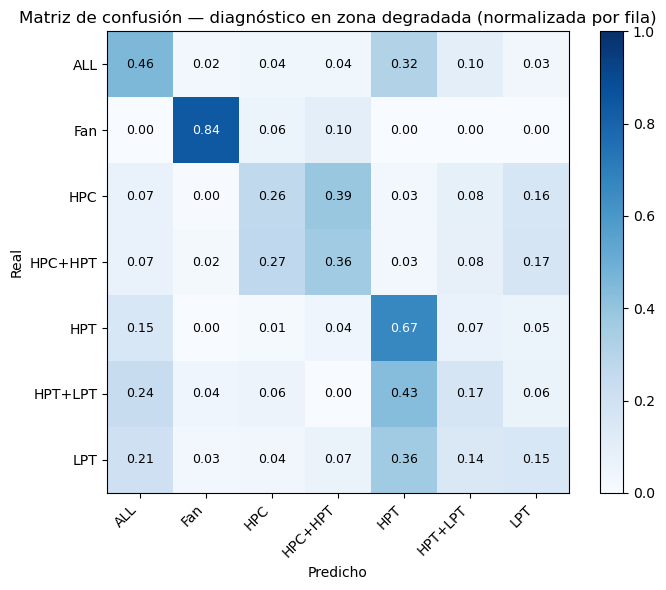

Figura guardada: confusion_diagnostico.png

LECTURA: mira qué pares se confunden. Si HPT / HPT+LPT / HPC+HPT se mezclan entre sí,
es física (comparten la degradación de HPT), no un fallo del modelo -> agrupar (celda 12).


In [6]:
# Matriz de confusión en zona degradada
cm = confusion_matrix(y_te[deg], pred[deg], normalize='true')
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                color='white' if cm[i,j] > 0.5 else 'black', fontsize=9)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — diagnóstico en zona degradada (normalizada por fila)')
plt.colorbar(im); plt.tight_layout()
plt.savefig('confusion_diagnostico.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figura guardada: confusion_diagnostico.png')
print('\nLECTURA: mira qué pares se confunden. Si HPT / HPT+LPT / HPC+HPT se mezclan entre sí,')
print('es física (comparten la degradación de HPT), no un fallo del modelo -> agrupar (celda 12).')

In [7]:
# Diagnóstico por MOTOR (voto mayoritario de sus ciclos degradados): la salida operativa real
rows = []
for eng in np.unique(eng_te):
    m = (eng_te == eng) & deg
    if m.sum() == 0: continue
    votos = np.bincount(pred[m], minlength=len(CLASSES))
    rows.append({'engine_id': eng, 'real': CLASSES[y_te[m][0]],
                 'predicho': CLASSES[votos.argmax()],
                 'confianza_voto': votos.max() / m.sum(), 'n_ciclos_deg': int(m.sum())})
por_motor = pd.DataFrame(rows)
por_motor['acierto'] = por_motor.real == por_motor.predicho
print(por_motor.to_string(index=False))
print(f'\nExactitud por MOTOR (voto mayoritario en zona degradada): '
      f'{por_motor.acierto.mean():.3f}  ({por_motor.acierto.sum()}/{len(por_motor)} motores)')

engine_id    real predicho  confianza_voto  n_ciclos_deg  acierto
 DS01_u10     HPT      HPT        1.000000            57     True
  DS01_u7     HPT      HPT        0.614035            57     True
  DS01_u8     HPT      HPT        0.701754            57     True
  DS01_u9     HPT      HPT        0.350877            57     True
 DS02_u11 HPT+LPT  HPT+LPT        1.000000            57     True
 DS02_u14 HPT+LPT      HPC        0.526316            57    False
 DS02_u15 HPT+LPT      ALL        0.894737            57    False
 DS03_u10 HPT+LPT      HPT        0.631579            57    False
 DS03_u11 HPT+LPT      HPT        0.385965            57    False
 DS03_u12 HPT+LPT      HPT        0.508772            57    False
 DS03_u13 HPT+LPT      HPT        0.596491            57    False
 DS03_u14 HPT+LPT      HPT        0.754386            57    False
 DS03_u15 HPT+LPT      HPT        1.000000            57    False
 DS04_u10     Fan      Fan        1.000000            57     True
  DS04_u7 

## 5. (Si hace falta) Agrupación en familias gruesas

Si la matriz de confusión muestra que los modos que comparten componente (HPT, HPT+LPT,
HPC+HPT) se confunden entre sí, la agrupación por zona del motor es la respuesta con
criterio: Turbina / Compresor / Fan / Mixto / Global. Ejecuta esta celda para re-evaluar el
MISMO modelo con las clases agrupadas (sin reentrenar): si la exactitud agrupada sube mucho,
la confusión era intra-familia, lo que confirma que el modelo capta la física correcta.

Clases agrupadas: ['Compresor', 'Fan', 'Global', 'Mixto_HPC_HPT', 'Turbina']
Exactitud agrupada (zona degradada): 0.569
F1 macro agrupado (degradada)      : 0.521


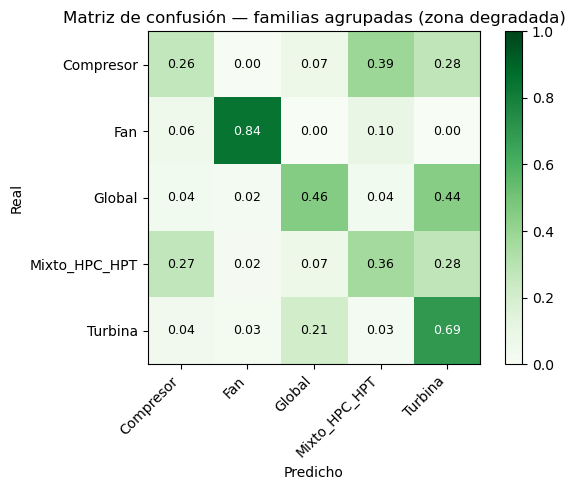

In [8]:
GROUP_CLASSES = sorted(set(GROUP.values()))
G_ID = {g: i for i, g in enumerate(GROUP_CLASSES)}
to_group = np.array([G_ID[GROUP[c]] for c in CLASSES])   # mapa clase fina -> gruesa

yg_te, pg_te = to_group[y_te], to_group[pred]
print('Clases agrupadas:', GROUP_CLASSES)
print(f'Exactitud agrupada (zona degradada): {accuracy_score(yg_te[deg], pg_te[deg]):.3f}')
print(f'F1 macro agrupado (degradada)      : {f1_score(yg_te[deg], pg_te[deg], average="macro"):.3f}')

cmg = confusion_matrix(yg_te[deg], pg_te[deg], normalize='true')
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(cmg, cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(len(GROUP_CLASSES))); ax.set_xticklabels(GROUP_CLASSES, rotation=45, ha='right')
ax.set_yticks(range(len(GROUP_CLASSES))); ax.set_yticklabels(GROUP_CLASSES)
for i in range(len(GROUP_CLASSES)):
    for j in range(len(GROUP_CLASSES)):
        ax.text(j, i, f'{cmg[i,j]:.2f}', ha='center', va='center',
                color='white' if cmg[i,j] > 0.5 else 'black', fontsize=9)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — familias agrupadas (zona degradada)')
plt.colorbar(im); plt.tight_layout()
plt.savefig('confusion_diagnostico_agrupado.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
import os as _os
_os.makedirs('modelos6', exist_ok=True)
clf.save('modelos6/cnn_diagnostico.keras')
joblib.dump({'MU': MU, 'SIGMA': SIGMA, 'WINDOW': WINDOW, 'FEATURES_SEQ': FEATURES_SEQ,
             'CLASSES': CLASSES, 'FAULT': FAULT, 'GROUP': GROUP, 'RUL_CAP': RUL_CAP},
            'modelos6/config_diagnostico.joblib')
print('Clasificador y config guardados en modelos6/.')

Clasificador y config guardados en modelos/.


## 6. Resultados obtenidos y lectura

**Cifras (zona degradada, que es donde el diagnóstico tiene sentido físico):** exactitud fina
**39% por ciclo** y **41% por motor** (7 clases, azar ≈ 14%); agrupando en familias por zona del
motor: **57%**. F1 macro 0,385.

**El desglose por clase es más revelador que la media:**

- **Fan: F1 0,82** — casi perfecto. Su firma física es la más distintiva y el modelo la aprende
  incluso con pocos motores.
- **HPT: recall 0,67 pero precisión 0,23** — es el "cajón de sastre": el modelo lo predice de más.
- **LPT (F1 0,18) y HPT+LPT (F1 0,23)** — los peores. Las confusiones se concentran entre los
  modos que comparten componentes de turbina.

**Lectura honesta:** el modelo capta la física correcta (distingue lo distinguible, confunde lo
físicamente parecido), pero la etiqueta fina exige más motores por clase de los que hay (5–6). La
granularidad sostenible es la **familia** (57%). La literatura respalda este límite: la mayoría de
trabajos sobre N-CMAPSS hacen prognosis, no diagnóstico de modo de fallo, precisamente por esta
dificultad.

**Siguientes pasos:** `Fase6b` prueba las mejoras que propone la literatura (ablación) y `Fase6c`
prueba la alternativa tabular (XGBoost) — la comparación decidirá el componente final.